# Feature Detection and Descriptors in OpenCV
*Harris, Shi–Tomasi, FAST, and ORB (Python)*

## Introduction

In the previous notebooks, we covered the basics of working with images using libraries such as `Pillow`, `scikit-image`, `SciPy`, and `NumPy`, followed by introductory `OpenCV` tasks like loading, resizing, cropping, and reshaping images.   

`OpenCV`, however, is designed for machine vision, and its real power shows up when we move beyond basic operations into topics like **feature detection**, **feature description**, and matching—the building blocks for problems such as **image registration**, **tracking**, and **alignment**. This tutorial introduces these ideas using several classic OpenCV methods.

---

## What Are Keypoints and Descriptors?

When you compare two images, especially if one is rotated, shifted, or distorted, you need stable “landmarks” that can be found in both images.

### Keypoints (Features)

A keypoint is a point or small region of interest that is distinctive enough to be recognized again.   

For example:
- A patch of blank sky usually has very little information, so it’s a poor keypoint.
- A sharp corner, textured boundary, or unique pattern is much better.   

Humans do this naturally: we recognize objects by matching recognizable parts. Feature detection is the computer vision equivalent.

### Detectors vs. Descriptors
- A **feature detector** finds where the keypoints are.
- A **feature descriptor** summarizes what the neighborhood looks like around each keypoint so those points can be matched later.

Some algorithms only detect keypoints, some only describe them, and the most practical options often do both.

---

## Why This Matters

Microscopy workflows often involve image drift:
- Long acquisitions
- Time-lapse imaging
- Serial sectioning (e.g., FIB-SEM / slicing workflows)

If images shift over time, feature-based methods can find corresponding keypoints across frames and help **align** images back to a reference—making registration far more robust than naive pixel-based methods.

Let's first do the rudimentary steps:   

**Import Libraries:**

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

**Load an image:**

In [19]:
img_path = "images/duck.jpg"

img_bgr = cv2.imread(img_path)  # color image (BGR in OpenCV)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
if img_bgr is None:
    raise FileNotFoundError(f"Could not read image at: {img_path}")

# Convert to grayscale (needed for most corner detectors)
gray_u8 = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

print("Image shape (BGR):", img_bgr.shape)
print("Gray dtype:", gray_u8.dtype, "| Gray shape:", gray_u8.shape)

Image shape (BGR): (360, 480, 3)
Gray dtype: uint8 | Gray shape: (360, 480)


**Helper function to visualize the image**

In [20]:
def show(img, title):
    if img.ndim == 3:
        cmap = "gray"
    else: 
        cmap = None
    
    img.ndim == 3 
    
    plt.imshow(img, cmap = cmap)
    if title:
        plt.title(title)
    plt.axis("off")
    plt.show

---

### 1) Harris Corner Detection

The first method introduced is Harris Corner Detection, one of the classic corner detectors.

**Workflow**
1) **Read** an image
2) Convert it to **grayscale**
3) Convert grayscale to `float32` (Harris expects float)
4) Run `cv2.cornerHarris()`
5) Threshold the response and mark “strong corners”

**How the Result Is Visualized**
Instead of returning a clean list of keypoints, Harris produces a *corner response map*—a matrix where “strong corner likelihood” values are high.

To visualize:
- Select points above a threshold (e.g., > 1% of max response)
- Color those pixels (commonly blue) on the original image

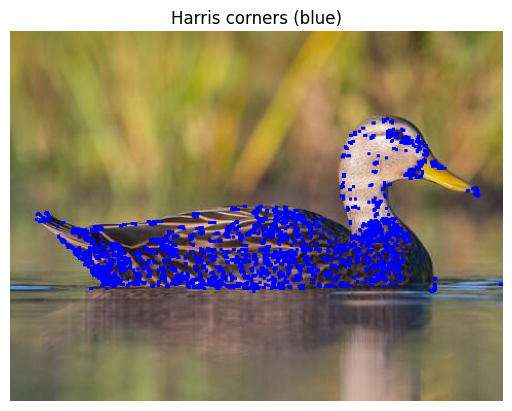

In [22]:
gray_f32 = np.float32(gray_u8)

# Parameters:
block_size = 2     # neighborhood size
ksize = 3          # Sobel aperture
k = 0.04           # Harris free parameter

harris_response = cv2.cornerHarris(gray_f32, block_size, ksize, k)

# Optional small improvement (common in OpenCV examples): dilate the response to mark corners more clearly
harris_response_dilated = cv2.dilate(harris_response, None)

# Threshold: "1% of max" (transcript)
threshold = 0.01 * harris_response_dilated.max()

# Mark detected corners in BLUE on a copy of the original
harris_vis = img_rgb.copy()
harris_vis[harris_response_dilated > threshold] = (0, 0, 255)  # BGR blue

show(harris_vis, "Harris corners (blue)")

# cv2.imshow("Harris corners (blue)", harris_vis)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

---

### 2) Shi–Tomasi Corner Detector (Good Features to Track)

Next is Shi–Tomasi, also known in OpenCV as **Good Features to Track**.   
This is often a practical improvement over Harris for many real-world cases.

**Key Idea**
Instead of a corner “heatmap,” it directly returns a list of corner coordinates:

- `N x 1 x 2` array of (x, y) positions

**Implementation Highlights**
- Use `cv2.goodFeaturesToTrack()`
- Specify:
    - Number of corners (e.g., 25 or 50)
    - Quality level (0–1)
    - Minimum distance between points (in pixels)

**Visualization**
Since it returns coordinates, we draw circles at those positions:
- Use `cv2.circle()` on the original image
- Helps confirm the detector is finding meaningful features



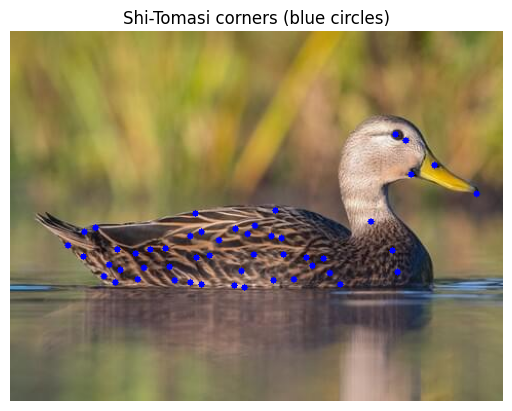

In [23]:
max_corners = 50
quality_level = 0.01
min_distance = 10

corners = cv2.goodFeaturesToTrack(
    gray_u8,
    maxCorners = max_corners,
    qualityLevel = quality_level,
    minDistance = min_distance
)

shi_vis = img_rgb.copy()

if corners is not None:
    corners = corners.astype(np.int32)  # transcript converts to int for drawing
    for c in corners:
        x, y = c.ravel()  # unwrap to x,y
        cv2.circle(shi_vis, (x, y), 3, (0, 0, 255), -1)  # small blue filled circle
        

show(shi_vis, "Shi-Tomasi corners (blue circles)")

# cv2.imshow("Shi-Tomasi corners (blue circles)", shi_vis)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

---

### 3) FAST Feature Detector

FAST stands for **Features from Accelerated Segment Test**.   

This is a fast and effective detector only (not a descriptor). It finds keypoints efficiently, often producing many useful points along edges and boundaries.

**Workflow**
1) Read a grayscale image
2) Create detector using `cv2.FastFeatureDetector_create()`
3) Detect keypoints
4) Draw keypoints onto the image with `cv2.drawKeypoints()`

**Why It’s Useful**

FAST can do a great job detecting lots of potential keypoints—especially along boundaries (like grain edges) and strong texture regions.

But remember:
- FAST is only a **detector**
- If you want to match features between images, you still need a descriptor

FAST keypoints: 2198


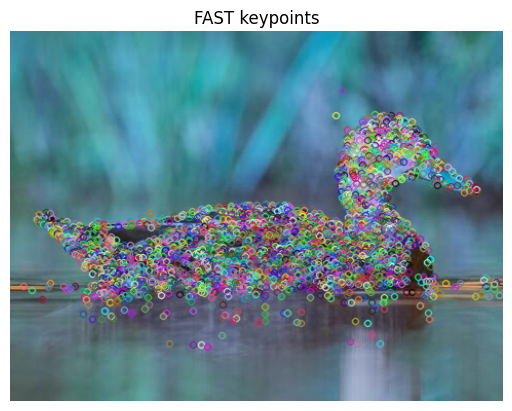

In [24]:
fast = cv2.FastFeatureDetector_create()
kp_fast = fast.detect(gray_u8, None)

fast_vis = cv2.drawKeypoints(
    img_bgr, kp_fast, None,
    flags=0  # transcript uses flags=0
)

print("FAST keypoints:", len(kp_fast))

show(fast_vis, "FAST keypoints")

# cv2.imshow("FAST keypoints", fast_vis)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

---

## 4) ORB: Oriented FAST + Rotated BRIEF

What is ORB? it combines:
- FAST (as the detector)
- BRIEF (as the descriptor)
- Plus orientation + rotation handling to improve matching

**Why ORB Is So Popular**
- **SIFT** and **SURF** used to be widely used, but faced patent restrictions
- They were available in OpenCV 2, but not in OpenCV 3+ by default
- ORB is an open alternative and is widely adopted

Even though many older papers reference SIFT, ORB is often “good enough” (and sometimes better) for modern pipelines—especially because it is easily available in OpenCV.

**ORB Implementation Flow**
1) **Read** grayscale image
2) Create **ORB object** using `cv2.ORB_create(nfeatures)`
3) Compute:
    - keypoints
    - descriptors: using `orb.detectAndCompute()`

**Visualization Options**
**A) Basic keypoints**
`cv2.drawKeypoints()` can plot keypoints, but the default display may not communicate much beyond location.

**B) Rich keypoints (recommended)**
Using the flag: `cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS`

This visualization adds:
- Circle size → indicates keypoint strength/scale
- Orientation line → indicates detected direction/angle of the feature

This gives a more informative view of what ORB is capturing.

ORB keypoints: 50
ORB descriptors: (50, 32) | dtype: uint8


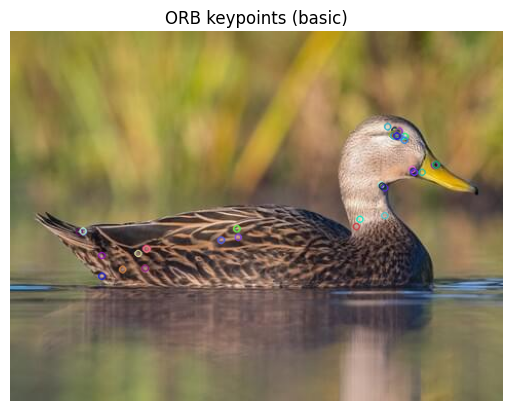

In [25]:
nfeatures = 50
orb = cv2.ORB_create(nfeatures)

kp_orb, des_orb = orb.detectAndCompute(gray_u8, None)

print("ORB keypoints:", len(kp_orb))
print("ORB descriptors:", None if des_orb is None else des_orb.shape, "| dtype:", None if des_orb is None else des_orb.dtype)

# Basic keypoint visualization
orb_vis_basic = cv2.drawKeypoints(img_rgb, kp_orb, None)

show(orb_vis_basic, "ORB keypoints (basic)")

# cv2.imshow("ORB keypoints (basic)", orb_vis_basic)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

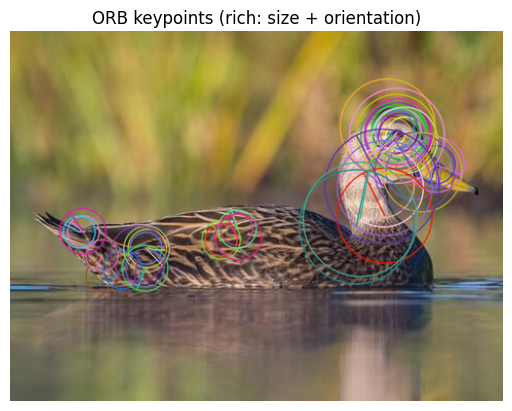

In [27]:
orb_vis_rich = cv2.drawKeypoints(
    img_rgb, kp_orb, None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

show(orb_vis_rich, "ORB keypoints (rich: size + orientation)")

# cv2.imshow("ORB keypoints (rich: size + orientation)", orb_vis_rich)
# cv2.waitKey(0)
# cv2.destroyAllWindows()


---

> Don't be worry!   
> We'll focus on these topics in next notebook practically!